# Sales Forecasting using Rossmann Dataset

**Objective:** Predict future store sales based on historical data using machine learning and time-series techniques.

**Dataset:** Rossmann Store Sales (train.csv)

**Models Used:** Linear Regression, Random Forest Regressor

**Evaluation Metrics:** MAE, RMSE, MAPE, R²

In [35]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
df = pd.read_csv('train.csv', dtype={'StateHoliday': str})

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (1017209, 9)
Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [38]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found — dataset is clean!')

df.describe()

No missing values found — dataset is clean!


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [39]:
len(df)

1017209

**Data Preprocessing**

Steps:
1. Convert `Date` column to datetime format
2. Sort by date (important for time-series)
3. Filter out closed stores (`Open == 0` rows have Sales = 0 and distort the model)
4. Encode `StateHoliday` properly — preserve the category (a=Public, b=Easter, c=Christmas)

In [40]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date').reset_index(drop=True)

df = df[df['Open'] == 1]

print(len(df))
print('Date range:', df['Date'].min(), 'to', df['Date'].max())

844392
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 27 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          844392 non-null  int64         
 1   DayOfWeek      844392 non-null  int64         
 2   Date           844392 non-null  datetime64[ns]
 3   Sales          844392 non-null  int64         
 4   Customers      844392 non-null  int64         
 5   Open           844392 non-null  int64         
 6   Promo          844392 non-null  int64         
 7   StateHoliday   844392 non-null  object        
 8   SchoolHoliday  844392 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 64.4+ MB


In [42]:
df['StateHoliday'].value_counts()

,count
StateHoliday,
0,843482
a,694
b,145
c,71


In [43]:
print('StateHoliday value counts')
print(df['StateHoliday'].value_counts())

holiday_dummies = pd.get_dummies(df['StateHoliday'], prefix='Holiday').astype(int)
holiday_dummies = holiday_dummies.drop(columns=['Holiday_0'], errors='ignore')
df = pd.concat([df, holiday_dummies], axis=1)

print('\nNew holiday columns added:', holiday_dummies.columns.tolist())

StateHoliday value counts
StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

New holiday columns added: ['Holiday_a', 'Holiday_b', 'Holiday_c']


In [44]:
df['StateHoliday'].value_counts()

,count
StateHoliday,
0,843482
a,694
b,145
c,71


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 27 to 1017208
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          844392 non-null  int64         
 1   DayOfWeek      844392 non-null  int64         
 2   Date           844392 non-null  datetime64[ns]
 3   Sales          844392 non-null  int64         
 4   Customers      844392 non-null  int64         
 5   Open           844392 non-null  int64         
 6   Promo          844392 non-null  int64         
 7   StateHoliday   844392 non-null  object        
 8   SchoolHoliday  844392 non-null  int64         
 9   Holiday_a      844392 non-null  int64         
 10  Holiday_b      844392 non-null  int64         
 11  Holiday_c      844392 non-null  int64         
dtypes: datetime64[ns](1), int64(10), object(1)
memory usage: 83.7+ MB


In [46]:
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Holiday_a,Holiday_b,Holiday_c
27,353,2,2013-01-01,3139,820,1,0,a,1,1,0,0
115,335,2,2013-01-01,2401,482,1,0,a,1,1,0,0
147,512,2,2013-01-01,2646,625,1,0,a,1,1,0,0
162,494,2,2013-01-01,3113,527,1,0,a,1,1,0,0
199,530,2,2013-01-01,2907,532,1,0,a,1,1,0,0
231,423,2,2013-01-01,9643,1751,1,0,a,1,1,0,0
310,85,2,2013-01-01,4220,619,1,0,a,1,1,0,0
455,274,2,2013-01-01,3102,729,1,0,a,1,1,0,0
467,262,2,2013-01-01,17267,2875,1,0,a,1,1,0,0
470,259,2,2013-01-01,6851,1444,1,0,a,1,1,0,0


### Feature Engineering

We extract Year, Month, Day, and DayOfWeek from the Date column to capture time-based patterns.

We also create Sales_lag_7, which stores sales from 7 days ago.

WHY: Past sales influence future sales, so this helps the model learn repeating patterns.

In [47]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek_num'] = df['Date'].dt.dayofweek

df['IsWeekend'] = df['DayOfWeek_num'].apply(lambda x: 1 if x >= 5 else 0)# 1 = weekends, 0 = weekday

In [48]:
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Holiday_a,Holiday_b,Holiday_c,Year,Month,Day,DayOfWeek_num,IsWeekend
27,353,2,2013-01-01,3139,820,1,0,a,1,1,0,0,2013,1,1,1,0
115,335,2,2013-01-01,2401,482,1,0,a,1,1,0,0,2013,1,1,1,0
147,512,2,2013-01-01,2646,625,1,0,a,1,1,0,0,2013,1,1,1,0
162,494,2,2013-01-01,3113,527,1,0,a,1,1,0,0,2013,1,1,1,0
199,530,2,2013-01-01,2907,532,1,0,a,1,1,0,0,2013,1,1,1,0
231,423,2,2013-01-01,9643,1751,1,0,a,1,1,0,0,2013,1,1,1,0
310,85,2,2013-01-01,4220,619,1,0,a,1,1,0,0,2013,1,1,1,0
455,274,2,2013-01-01,3102,729,1,0,a,1,1,0,0,2013,1,1,1,0
467,262,2,2013-01-01,17267,2875,1,0,a,1,1,0,0,2013,1,1,1,0
470,259,2,2013-01-01,6851,1444,1,0,a,1,1,0,0,2013,1,1,1,0


**EDA Visualizations**

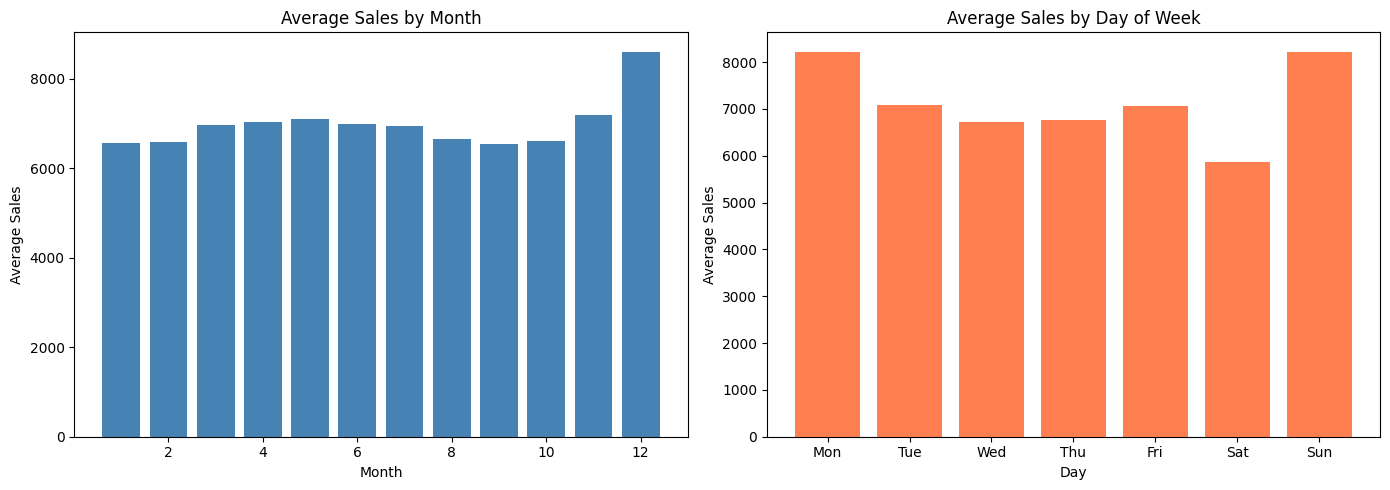

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Sales per Month
monthly_avg = df.groupby('Month')['Sales'].mean()
axes[0].bar(monthly_avg.index, monthly_avg.values, color='steelblue')
axes[0].set_title('Average Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales')

# Average Sales per Day of Week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg = df.groupby('DayOfWeek_num')['Sales'].mean()
axes[1].bar(range(len(dow_avg)), dow_avg.values, color='coral')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Sales')

plt.tight_layout()
plt.show()


### Feature Selection

We select important features like store info, promotions, holidays, time features, and Sales_lag_7.

WHY: The model can only learn from given features, so relevant inputs improve predictions.

In [50]:
#Feature Engineering (Year, Month, etc.)
df = df.sort_values(['Store', 'Date'])
df['Sales_lag_7'] = df.groupby('Store')['Sales'].shift(7)
df = df.dropna(subset=['Sales_lag_7']).reset_index(drop=True)

feature_columns = [
    'Store',
    'DayOfWeek',
    'Promo',
    'SchoolHoliday',
    'Holiday_a',
    'Holiday_b',
    'Holiday_c',
    'Year',
    'Month',
    'Day',
    'DayOfWeek_num',
    'IsWeekend',
    'Sales_lag_7'
]

target_column = 'Sales'# Target is what we want to predict

In [51]:
print(df[['Sales', 'Sales_lag_7']].head(10))

   Sales  Sales_lag_7
0   4892       5530.0
1   4881       4327.0
2   4952       4486.0
3   4717       4997.0
4   3900       7176.0
5   4008       5580.0
6   4044       5471.0
7   4127       4892.0
8   5182       4881.0
9   5394       4952.0


**Train / Test Split**

Using **time-based split** — training on data before 2015, testing on 2015 onwards. This is the correct approach for time-series (never use random split on time data).

In [52]:
#Spliting data based on time not randomly
cutoff_date = '2015-01-01'

train = df[df['Date'] < cutoff_date]

test  = df[df['Date'] >= cutoff_date]

#Separate features(X) and target(y)
X_train = train[feature_columns]
y_train = train[target_column]

X_test  = test[feature_columns]
y_test  = test[target_column]

print('Training set size:', len(X_train), 'rows')
print('Testing set size :', len(X_test),  'rows')
print('Training period:', train['Date'].min(), 'to', train['Date'].max())
print('Testing period :', test['Date'].min(),  'to', test['Date'].max())


Training set size: 640555 rows
Testing set size : 196032 rows
Training period: 2013-01-08 00:00:00 to 2014-12-31 00:00:00
Testing period : 2015-01-01 00:00:00 to 2015-07-31 00:00:00


### Linear Regression

We use Linear Regression as a simple baseline model.

It helps compare performance with more advanced models.

In [53]:
# IMPROVEMENT 1 (cont.) — renamed 'model' to 'lr_model' for clarity
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print('Number of features used:', len(feature_columns))
print('Feature coefficients (weights):')
for feat, coef in zip(feature_columns, lr_model.coef_):
    print(f'  {feat:20s}: {coef:.2f}')

Number of features used: 13
Feature coefficients (weights):
  Store               : 0.03
  DayOfWeek           : -130.10
  Promo               : 3501.53
  SchoolHoliday       : -107.54
  Holiday_a           : 677.11
  Holiday_b           : 1983.88
  Holiday_c           : 496.44
  Year                : 38.28
  Month               : 37.04
  Day                 : 9.13
  DayOfWeek_num       : -130.10
  IsWeekend           : 1294.67
  Sales_lag_7         : 0.67


In [54]:
# predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_lr = np.maximum(y_pred_lr, 0)

# predictions vs actual
comparison = pd.DataFrame({
    'Actual Sales':    y_test.values[:10],
    'Predicted Sales': y_pred_lr[:10].astype(int)
})
print('First 10 predictions vs actual:')
print(comparison.to_string(index=False))

First 10 predictions vs actual:
 Actual Sales  Predicted Sales
         5509             6002
         5023             6131
         6239             6791
         4574             8138
         4796             8158
         3716             7909
         3998             5084
         4599             4669
         5346             7872
         4924             8431


### Random Forest

Random Forest builds multiple trees to make predictions.

It captures complex patterns better than Linear Regression.

In [55]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=10, n_jobs=-1,
                      random_state=42)

In [56]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf = np.maximum(y_pred_rf, 0)

comparison_rf = pd.DataFrame({
    'Actual Sales':      y_test.values[:10],
    'RF Predicted Sales': y_pred_rf[:10].astype(int)
})

print('Random Forest Predictions (first 10):')
print(comparison_rf.to_string(index=False))

Random Forest Predictions (first 10):
 Actual Sales  RF Predicted Sales
         5509                6097
         5023                6384
         6239                7802
         4574                9067
         4796                9004
         3716                7112
         3998                5732
         4599                4500
         5346                8287
         4924                7250


###Model Evaluation Using Time-Series Metrics

We use MAE, RMSE, MAPE, and R² to evaluate performance.
These metrics show how accurate the model predictions are.

In [57]:
def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f'  {model_name}')
    print(f'  MAE  (Mean Absolute Error)       : {mae:,.2f}')
    print(f'  RMSE (Root Mean Squared Error)   : {rmse:,.2f}')
    print(f'  MAPE (Mean Abs Percentage Error) : {mape:.2f}%')
    print(f'  R²   (R-squared Score)           : {r2:.4f}')
    print()
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

metrics_lr = evaluate_model(y_test.values, y_pred_lr, 'Linear Regression')
metrics_rf = evaluate_model(y_test.values, y_pred_rf, 'Random Forest')

print('IMPROVEMENT SUMMARY (RF vs LR):')
for metric in ['MAE', 'RMSE', 'MAPE']:
    improvement = ((metrics_lr[metric] - metrics_rf[metric]) / metrics_lr[metric]) * 100
    print(f'  {metric}: Random Forest is {improvement:.1f}% better than Linear Regression')

  Linear Regression
  MAE  (Mean Absolute Error)       : 1,510.92
  RMSE (Root Mean Squared Error)   : 2,030.91
  MAPE (Mean Abs Percentage Error) : 23.79%
  R²   (R-squared Score)           : 0.5520

  Random Forest
  MAE  (Mean Absolute Error)       : 1,362.66
  RMSE (Root Mean Squared Error)   : 1,903.41
  MAPE (Mean Abs Percentage Error) : 21.22%
  R²   (R-squared Score)           : 0.6065

IMPROVEMENT SUMMARY (RF vs LR):
  MAE: Random Forest is 9.8% better than Linear Regression
  RMSE: Random Forest is 6.3% better than Linear Regression
  MAPE: Random Forest is 10.8% better than Linear Regression


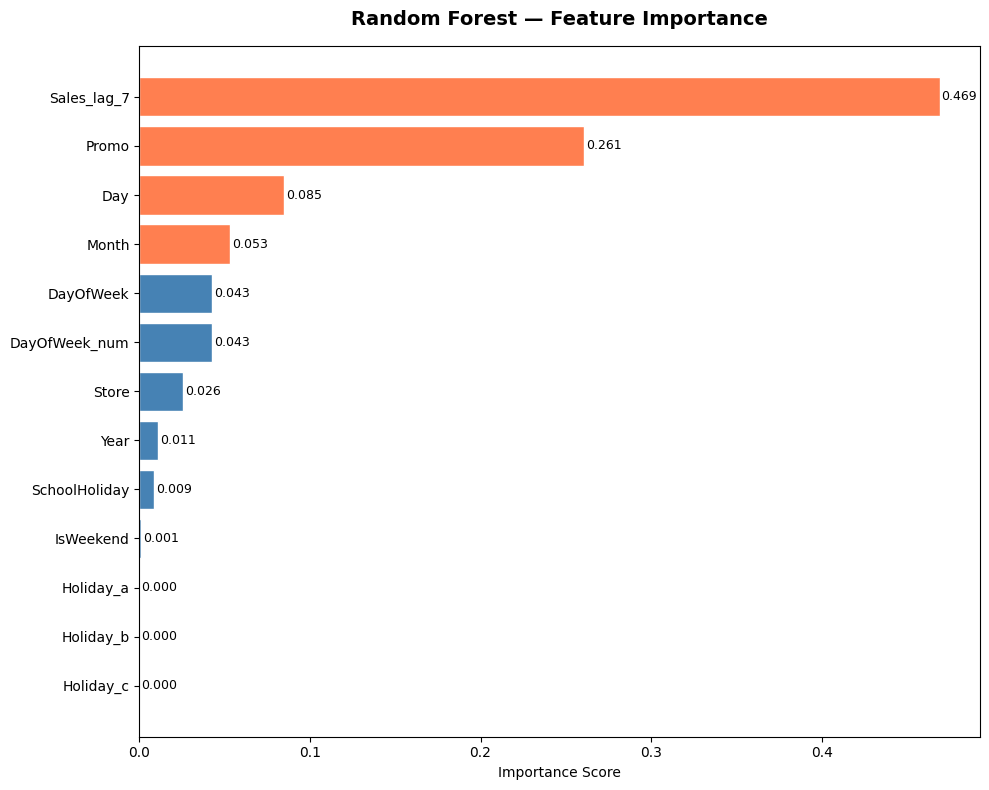


Top 5 most important features:
Sales_lag_7    0.469149
Promo          0.260728
Day            0.084875
Month          0.053410
DayOfWeek      0.042843


In [58]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if v < importances.quantile(0.75) else 'coral'
          for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')

ax.set_title('Random Forest — Feature Importance', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score')
ax.axvline(x=0, color='black', linewidth=0.5)

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head(5).to_string())

**Visualization** Actual vs Predicted

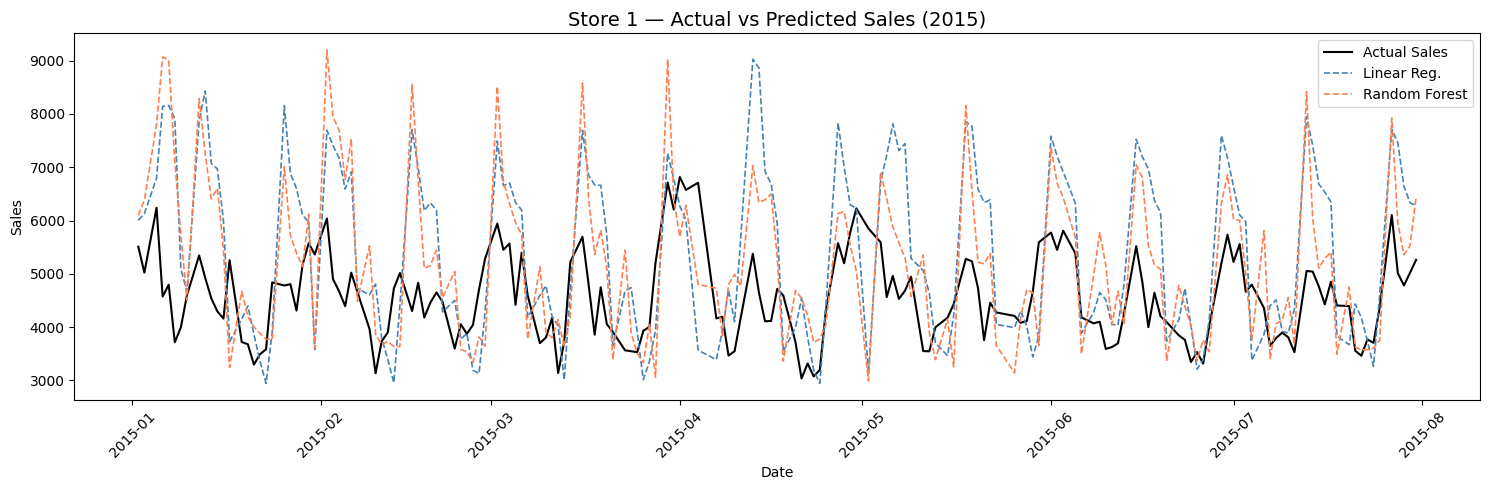

In [59]:
test_reset  = test.reset_index(drop=True)
store1_mask = test_reset['Store'] == 1

actual_s1   = y_test.values[store1_mask.values]
pred_lr_s1  = y_pred_lr[store1_mask.values]
pred_rf_s1  = y_pred_rf[store1_mask.values]
dates_s1    = test_reset[store1_mask]['Date'].values

plt.figure(figsize=(15, 5))
plt.plot(dates_s1, actual_s1,  label='Actual Sales',  color='black',     linewidth=1.5)
plt.plot(dates_s1, pred_lr_s1, label='Linear Reg.',   color='steelblue', linewidth=1.2, linestyle='--')
plt.plot(dates_s1, pred_rf_s1, label='Random Forest', color='coral',     linewidth=1.2, linestyle='--')
plt.title('Store 1 — Actual vs Predicted Sales (2015)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

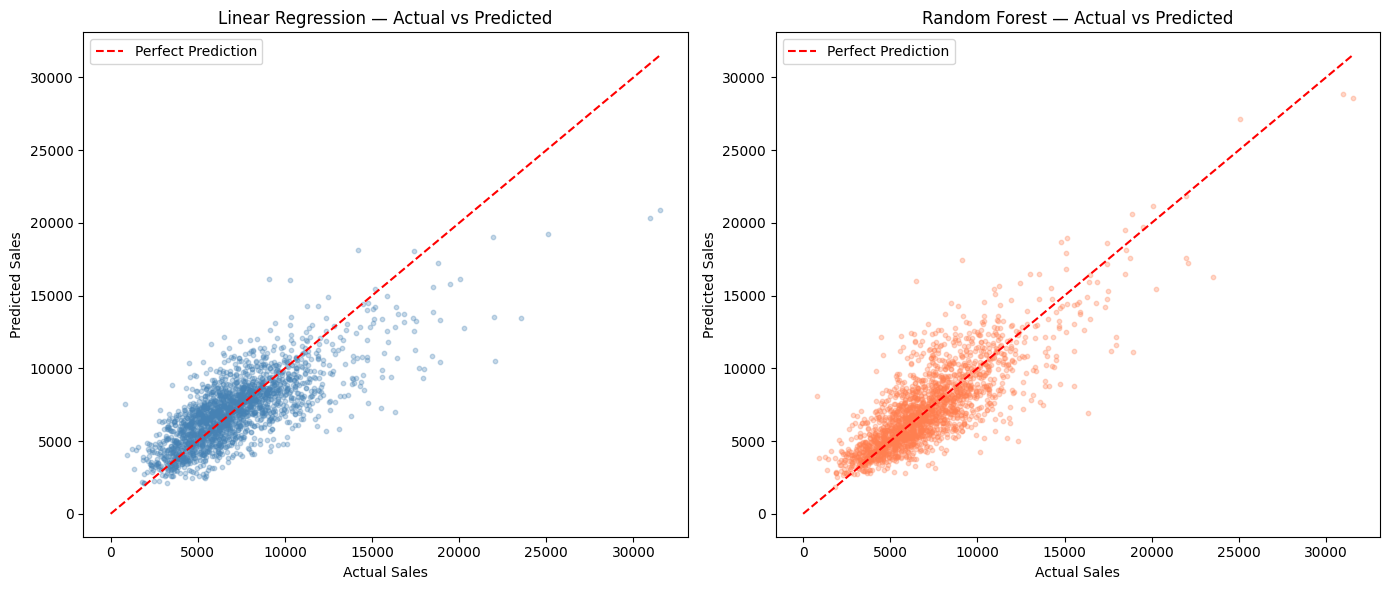

In [60]:
sample_idx = np.random.choice(len(y_test), size=2000, replace=False)
actual_s   = np.array(y_test)[sample_idx]
pred_lr_s  = y_pred_lr[sample_idx]
pred_rf_s  = y_pred_rf[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, title, color in zip(
    axes,
    [pred_lr_s, pred_rf_s],
    ['Linear Regression', 'Random Forest'],
    ['steelblue', 'coral']
):
    ax.scatter(actual_s, preds, alpha=0.3, color=color, s=10)
    max_val = max(actual_s.max(), preds.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
    ax.set_title(f'{title} — Actual vs Predicted', fontsize=12)
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')
    ax.legend()

plt.tight_layout()
plt.show()

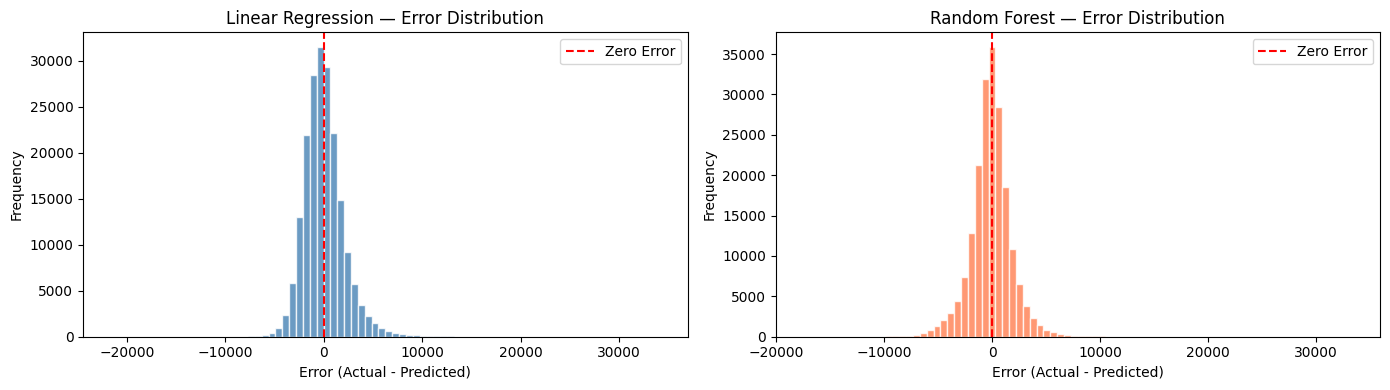

In [61]:
errors_lr = np.array(y_test) - y_pred_lr
errors_rf = np.array(y_test) - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, errors, title, color in zip(
    axes,
    [errors_lr, errors_rf],
    ['Linear Regression', 'Random Forest'],
    ['steelblue', 'coral']
):
    ax.hist(errors, bins=80, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', label='Zero Error')
    ax.set_title(f'{title} — Error Distribution', fontsize=12)
    ax.set_xlabel('Error (Actual - Predicted)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()


## Conclusion

### Results Summary

| Metric | Linear Regression | Random Forest | Winner |
|--------|-------------------|---------------|--------|
| MAE    | 1,510.92 | 1,362.66 | Random Forest |
| RMSE   | 2,030.91 | 1,903.41 | Random Forest |
| MAPE   | 23.79% | 21.22% | Random Forest |
| R²     | 0.5520 | 0.6065 | Random Forest |

### Key Findings

1. Random Forest outperformed Linear Regression across all evaluation metrics, showing its ability to capture non-linear patterns in sales data.
2. Model performance improved after adding the lag feature (Sales_lag_7), demonstrating that past sales play a crucial role in predicting future sales.
3. Promotional activity (Promo) has a strong impact on sales, significantly influencing demand patterns.
4. Seasonal trends are clearly visible, with higher sales observed during peak months such as November and December.

### What I Would Do Next (Future Improvements)

- Add more lag features (e.g., 14-day, 30-day) for better temporal understanding
- Include external features such as store metadata (store.csv)
- Apply advanced models like XGBoost or LightGBM
- Perform hyperparameter tuning to optimize model performance